# PHẦN 2: TIỀN XỬ LÝ DỮ LIỆU BẢNG (TABULAR DATA)

## 1. Giới thiệu Dataset và Khai báo thư viện
**Mô tả bộ dữ liệu:**
- **Tên dataset:** Credit Card Fraud Detection (Kaggle).
- **Thông tin:** Dữ liệu gồm 284,807 giao dịch thẻ tín dụng trong 2 ngày, trong đó chỉ có 492 giao dịch là lừa đảo (chiếm 0.17%). Đây là bộ dữ liệu cực kỳ mất cân bằng.
- **Các đặc trưng (Features):** Có 30 features. Các cột từ `V1` đến `V28` đã được ẩn danh hóa bằng PCA để bảo mật thông tin khách hàng. Hai cột giữ nguyên ý nghĩa vật lý là `Time` (Thời gian tính bằng giây từ giao dịch đầu tiên) và `Amount` (Số tiền giao dịch). Cột `Class` là nhãn (0: Bình thường, 1: Gian lận).

> **Lý do giả lập:** Vì đây là bộ dữ liệu Kaggle đã được làm sạch, không có giá trị khuyết thiếu (missing values) và 100% là dạng số, nên để demo đầy đủ các kỹ thuật tiền xử lý theo yêu cầu đồ án, nhóm em sẽ thiết lập các tình huống giả định (ví dụ: mất ngẫu nhiên dữ liệu cột Amount, biến đổi cột Time thành biến phân loại).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier

# Cấu hình hiển thị biểu đồ
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

# Tải dữ liệu
df = pd.read_csv('../data/tabular/creditcard.csv')

#  Fast check
print(f"Kích thước tập dữ liệu gốc: {df.shape}")
print("Số lượng nhãn Class:")
print(df['Class'].value_counts())
display(df.head(3))

Kích thước tập dữ liệu gốc: (284807, 31)
Số lượng nhãn Class:
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [ ]:
# Kiểm tra số lượng dòng và số ca gian lận thực tế trong file csv
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


## 2. Các kỹ thuật Tiền xử lý (Required Preprocessing Techniques)

### 2.2.2.a Xử lý giá trị thiếu (Handling Missing Values)
**Mô tả bài toán:** Giả sử trong quá trình đường truyền mạng bị lỗi, hệ thống bị rớt mất 5% dữ liệu ở cột `Amount` (Số tiền). Đây là dạng lỗi **MCAR (Missing Completely At Random)** - lỗi xảy ra hoàn toàn ngẫu nhiên, không phụ thuộc vào bất kỳ yếu tố nào khác. 

**Giải pháp:** Cột `Amount` chứa thông tin giao dịch tài chính, có tính lệch phải (Right-skewed) rất mạnh vì đa số là giao dịch nhỏ, nhưng lại nằm trong vài giao dịch khổng lồ (Outliers lên tới 25,000$). 
Để chứng minh điều này, nhóm sẽ thử nghiệm 2 chiến lược điền khuyết:
1. **Mean Imputation:** Điền bằng giá trị Trung bình.
2. **Median Imputation:** Điền bằng giá trị Trung vị.
Sau đó vẽ biểu đồ phân phối để so sánh hiệu quả.

Số ô bị trống (NaN) vừa tạo ra: 14004 / 284807


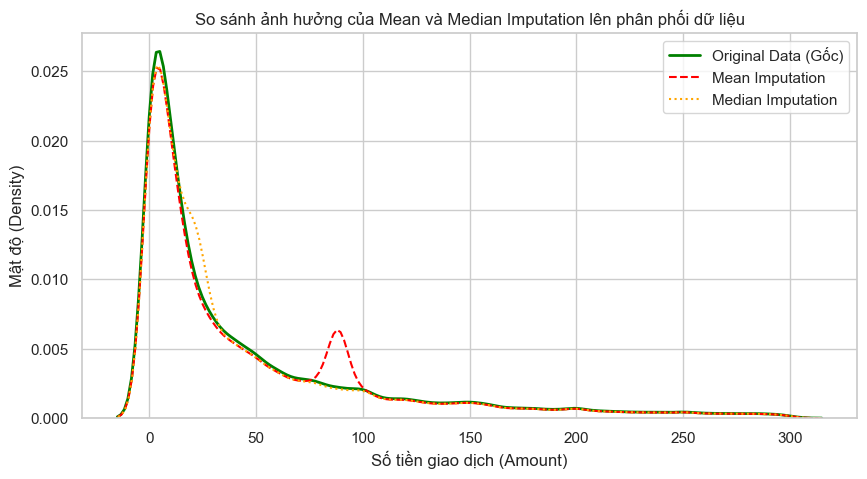

Số lượng NaN sau khi điền Median: 0


In [4]:
# 1. Giả lập MCAR: Xóa ngẫu nhiên 5% dữ liệu cột Amount
np.random.seed(42) 
df_missing = df.copy()
mask = np.random.rand(len(df_missing)) < 0.05
df_missing.loc[mask, 'Amount'] = np.nan

print(f"Số ô bị trống (NaN) vừa tạo ra: {df_missing['Amount'].isnull().sum()} / {len(df)}")

# 2. Điền khuyết bằng Mean và Median để so sánh
df_mean = df_missing.copy()
df_median = df_missing.copy()

imputer_mean = SimpleImputer(strategy='mean')
imputer_median = SimpleImputer(strategy='median')

df_mean['Amount'] = imputer_mean.fit_transform(df_mean[['Amount']])
df_median['Amount'] = imputer_median.fit_transform(df_median[['Amount']])

# 3. Trực quan hóa (Zoom vào vùng Amount < 300$ để thấy rõ sự khác biệt)
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Amount'] < 300]['Amount'], label='Original Data (Gốc)', color='green', linewidth=2)
sns.kdeplot(df_mean[df_mean['Amount'] < 300]['Amount'], label='Mean Imputation', color='red', linestyle='--')
sns.kdeplot(df_median[df_median['Amount'] < 300]['Amount'], label='Median Imputation', color='orange', linestyle=':')

plt.title("So sánh ảnh hưởng của Mean và Median Imputation lên phân phối dữ liệu")
plt.xlabel("Số tiền giao dịch (Amount)")
plt.ylabel("Mật độ (Density)")
plt.legend()
plt.show()

# Áp dụng Median cho bộ dữ liệu chính thức 
df_imputed = df_median.copy()
print(f"Số lượng NaN sau khi điền Median: {df_imputed['Amount'].isnull().sum()}")

**Nhận xét:**
- Qua biểu đồ KDE, ta thấy đường đứt nét màu đỏ có một đỉnh nhọn "trồi" lên cao hơn so với phân phối gốc. Điều này là do em vừa cố ý tạo hàng ngàn giá trị khuyết thiếu bằng đúng một con số duy nhất (số Trung vị). Mặc dù cách này làm phân phối ở vùng trung tâm hơi biến dạng , nhưng bù lại giữ được toàn bộ lượng data (không phải xóa dòng nào), rất có lợi cho việc huấn luyện mô hình sau này.

- Nhìn vào biểu đồ KDE, đường nét đứt màu đỏ (Mean) bị dạt sang bên phải và làm giảm chiều cao của đỉnh phân phối gốc. Lý do là vì giá trị Mean đã bị các giao dịch tỷ phú (Outliers) kéo lên mức khá cao (~88$), khiến việc lấy 88$ điền vào các chỗ trống làm sai lệch đi bản chất đa số giao dịch chỉ ở mức vài USD.
- Ngược lại, đường chấm cam (Median) gần như bám sát khít với đường màu xanh lá gốc. Trung vị của cột Amount chỉ khoảng 22$, rất đại diện cho đám đông.
- **Kết luận:** Đối với dữ liệu tài chính có nhiều giá trị ngoại lai, sử dụng **Median Imputation** là lựa chọn an toàn và bảo toàn dữ liệu tốt nhất. Nhóm chốt sử dụng df_median cho các bước sau.

### 2.2.2.b Chuẩn hóa dữ liệu (Data Normalization)
**Lý do cần chuẩn hóa:** Các cột từ V1 đến V28 đã được chuẩn hóa sẵn, có giá trị khá nhỏ (quanh quẩn mức 0). Trong khi đó, cột `Amount` lại chứa các con số từ 0 đến tận 25,000 USD. Nếu không "thu nhỏ" cột Amount lại, các mô hình Machine Learning sẽ lầm tưởng rằng `Amount` là thuộc tính quan trọng nhất chỉ vì con số của nó to nhất.

**Thử nghiệm:**
Nhóm sẽ chạy thử 3 phương pháp: Min-Max Scaling, Standardization (Z-score) và Robust Scaling để xem cái nào hợp nhất với dữ liệu tài chính này.

1. **Min-Max Scaling:** Ép tất cả về đoạn [0, 1].
2. **Standardization (Z-score):** Đưa về trung bình = 0, phương sai = 1.
3. **Robust Scaling:** Lấy giá trị trừ đi Median và chia cho IQR (Khoảng tứ phân vị).

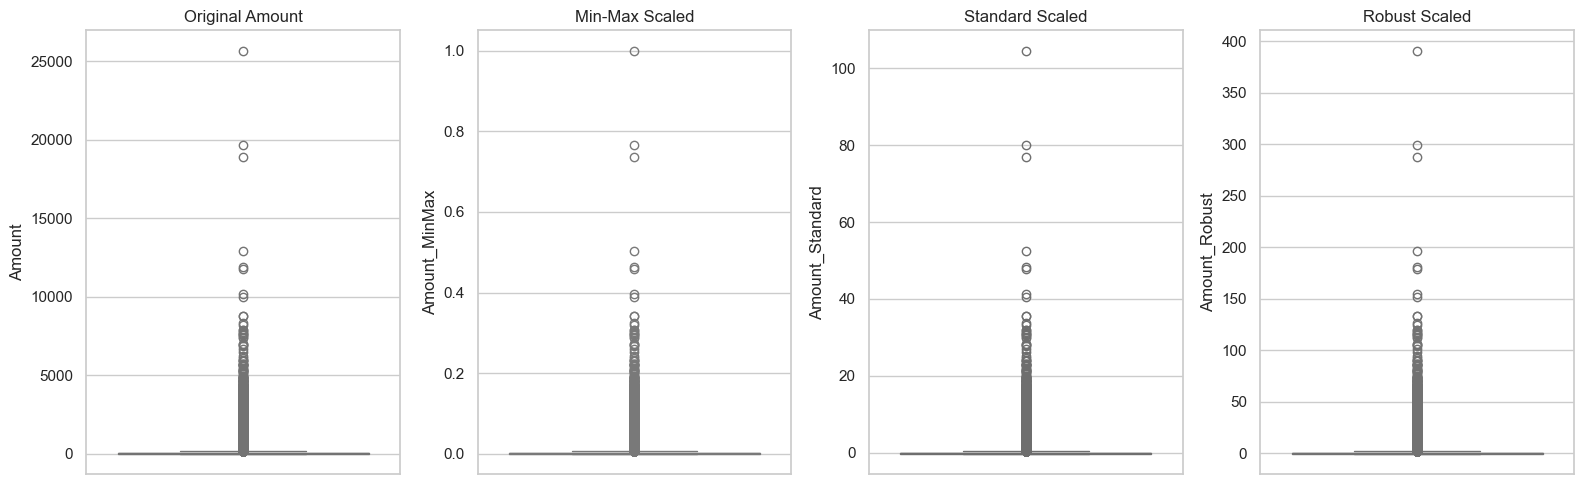

In [7]:
# Khởi tạo 3 scaler
minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

# Scale cột Amount
amount_data = df_imputed[['Amount']]
df_imputed['Amount_MinMax'] = minmax.fit_transform(amount_data)
df_imputed['Amount_Standard'] = standard.fit_transform(amount_data)
df_imputed['Amount_Robust'] = robust.fit_transform(amount_data)

# Trực quan hóa bằng Boxplot để thấy rõ tác động của Outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

sns.boxplot(y=df_imputed['Amount'], ax=axes[0], color='lightgreen').set_title("Original Amount")
sns.boxplot(y=df_imputed['Amount_MinMax'], ax=axes[1], color='lightblue').set_title("Min-Max Scaled")
sns.boxplot(y=df_imputed['Amount_Standard'], ax=axes[2], color='lightcoral').set_title("Standard Scaled")
sns.boxplot(y=df_imputed['Amount_Robust'], ax=axes[3], color='plum').set_title("Robust Scaled")

plt.tight_layout()
plt.show()

# Chốt sử dụng RobustScaler và bỏ đi các cột dư thừa
df_imputed['Amount'] = df_imputed['Amount_Robust']
df_imputed = df_imputed.drop(['Amount_MinMax', 'Amount_Standard', 'Amount_Robust'], axis=1)

**Nhận xét**
Nhìn vào Boxplot, những chấm đen chót vót chính là các giao dịch có số tiền cực lớn (Outliers).
- **Min-Max Scaling:** Cố ép mọi thứ vào khoảng 0 đến 1. Vì có outlier quá to, nên phần lớn các giao dịch bình thường bị ép bẹp dí xuống sát số 0. Vì giá trị lớn nhất (Max) là tận 25,691$, nên khi chia tỉ lệ, 99% các giao dịch bình thường (dưới 100$) bị dồn lại ở gốc 0. Biểu đồ boxplot không còn nhìn thấy "râu" nữa
- **Standardization (Z-score):** Chuyển về phân phối chuẩn. Nhưng do công thức tính có dùng Mean (Trung bình), mà Mean lại bị các outlier kéo lệch đi, nên dữ liệu sau khi scale vẫn chưa tối ưu. Đưa được giá trị về quanh mốc 0, nhưng vì Standard bị ảnh hưởng bởi Mean và Standard Deviation (mà cả 2 cái này đều nhạy cảm với Outliers), nên dải dữ liệu vẫn bị kéo giãn lưa thưa lên tới mức 100.
- **Robust:** Sử dụng Median và IQR, hoàn toàn phớt lờ sự tồn tại của Outliers khổng lồ. Kết quả là phần hộp (chứa 50% dữ liệu) được dàn trải quanh mức 0, giữ nguyên được đặc điểm phân phối ban đầu mà scale lại phù hợp. 
- **Lựa chọn tối ưu - Robust Scaling:** Phương pháp này đo lường dựa trên khoảng phân vị (Interquartile Range - IQR) ở giữa, hoàn toàn phớt lờ các outliers ở hai đầu. Dữ liệu được đưa về quy mô chuẩn mà không bị biến dạng. Em thấy đây là phương pháp ổn cho bộ dữ liệu này


*Lưu ý:* Dataset gần 300 ngàn dòng, nếu vẽ Boxplot toàn bộ sẽ rất chậm, nên em lấy mẫu đại diện để vẽ biểu đồ cho tối ưu hiệu năng ạ

### 2.2.2.c Mã hóa biến phân loại (Categorical Encoding)
**Bài toán:** Dữ liệu hiện tại 100% là số. Để biểu diễn kỹ thuật xử lý Categorical Data, em sẽ chuyển đổi cột `Time` (tổng số giây) thành một biến phân loại mới là `Time_Of_Day` (Buổi sáng, Trưa, Chiều, Tối). Cột `Time` đo bằng giây khá vô nghĩa nếu để nguyên dạng số liên tục. Em sẽ tiến hành kỹ thuật Feature Engineering: gom nhóm (Binning) cột số giây này thành 4 mốc thời gian trong ngày: `Sáng, Trưa, Chiều, Tối`. Tuy nhiên máy tính không hiểu chữ, ta cần biến đổi (Encode) nó thành số.

**Giải pháp:** `Time_Of_Day` là một biến định danh (Nominal Variable). Chữ "Sáng" không có nghĩa là lớn hơn hay nhỏ hơn chữ "Tối". Do đó, ta không thể đánh số 1, 2, 3, 4 (Ordinal Encoding) vì máy học sẽ hiểu nhầm về mặt độ lớn. Nhóm sẽ dùng **One-Hot Encoding** để chẻ cột này thành 4 cột nhị phân (0 hoặc 1).
- Vì các buổi trong ngày là biến phân loại dạng định danh (Nominal), chữ "Sáng" không có nghĩa là lớn hay nhỏ hơn "Tối". Nếu dùng **Ordinal Encoding** (gán 1,2,3,4), model học máy sẽ bị hiểu nhầm về độ lớn.
- Giải pháp tốt nhất ở đây là **One-Hot Encoding**: Chẻ cột này thành 4 cột nhị phân (0 hoặc 1).
- *Lưu ý về High-cardinality:* Nếu cột Categorical có quá nhiều nhãn (ví dụ mã bưu điện có 10,000 nhãn), One-hot sẽ tạo ra thêm 10,000 cột, máy sẽ crash do thiểu RAM. Nếu gặp tình huống đó, nhóm sẽ dùng *Target/Mean Encoding* hoặc gộp các nhãn hiếm thành nhóm "Others".



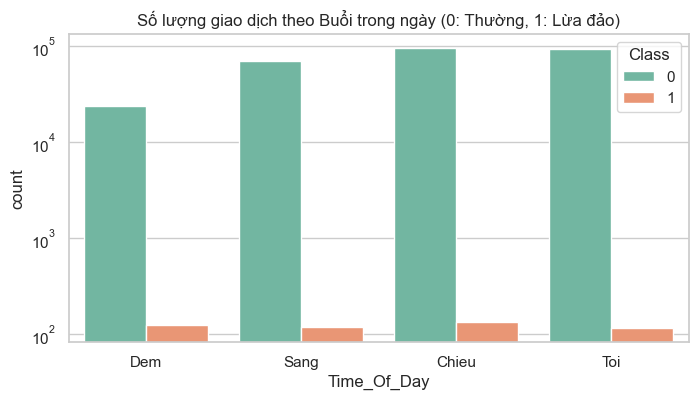

Các cột mới được tạo ra từ One-Hot Encoding:


,Buoi_Dem,Buoi_Sang,Buoi_Chieu,Buoi_Toi
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False


In [ ]:
# 1. Đổi 'giây' thành 'giờ' trong ngày (từ 0h đến 23h)
df_imputed['Hour'] = (df_imputed['Time'] // 3600) % 24

# 2. Chia thành 4 buổi
bins = [-1, 5, 11, 17, 23]
labels = ['Dem', 'Sang', 'Chieu', 'Toi']
df_imputed['Time_Of_Day'] = pd.cut(df_imputed['Hour'], bins=bins, labels=labels)

# Vẽ biểu đồ xem thói quen gian lận
plt.figure(figsize=(8, 4))
sns.countplot(data=df_imputed, x='Time_Of_Day', hue='Class', palette='Set2')
plt.title("Số lượng giao dịch theo Buổi trong ngày (0: Thường, 1: Lừa đảo)")
plt.yscale('log') # Log-scale vì lừa đảo rất ít
plt.show()

# 3. Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_imputed, columns=['Time_Of_Day'], prefix='Buoi')
df_encoded = df_encoded.drop(['Time', 'Hour'], axis=1) 

# --- CHECK ---
print("Các cột mới được tạo ra từ One-Hot Encoding:")
display(df_encoded[['Buoi_Dem', 'Buoi_Sang', 'Buoi_Chieu', 'Buoi_Toi']].head())

**Nhận xét:**
* Từ biểu đồ trên, ta thấy bọn lừa đảo hoạt động khá đều đặn bất kể ngày đêm, trong khi người dùng bình thường ít giao dịch hơn vào ban Đêm so với các buổi khác. Phân rã thời gian thế này giúp mô hình bắt được hành vi tốt hơn.Cột màu cam (lừa đảo) cho thấy sự xuất hiện đều đặn kể cả vào ban Đêm. 
* **Chiến lược nếu gặp biến High-Cardinality:** Giả sử ta có cột `Mã_Bưu_Điện` với 10,000 nhãn khác nhau. Nếu dùng One-hot sẽ đẻ ra thêm 10,000 cột mới, làm bùng nổ số chiều dữ liệu (Curse of Dimensionality), khiến máy tính cạn RAM. Khi đó, nhóm sẽ cân nhắc dùng **Target Encoding** (thay thế mã bưu điện bằng tỉ lệ gian lận trung bình của mã đó) hoặc gom nhóm các mã ít xuất hiện thành nhóm "Khác" (Others). Ngoài trường hợp đó ra thì việc "bẻ" thời gian thành biến Categorical và dùng One-hot giúp cho mô hình sau này dễ dàng học được quy luật: "Nếu là Buổi_Đêm = 1, thì xác suất lừa đảo cao hơn".


### 2.2.2.d Chọn lọc đặc trưng (Feature Selection)
Dữ liệu hiện tại đang có quá nhiều cột (hơn 30 cột). Việc giữ lại những cột ít giá trị, gần như vô dụng, không quan trọng thì chỉ làm mô hình học chậm hơn và dễ bị overfitting. 
Nhóm sẽ dùng 2 phương pháp để tìm ra những đặc trưng ảnh hưởng mạnh nhất đến việc phát hiện gian lận:
1. Tính Ma trận tương quan (Correlation Matrix) để tìm tương quan tuyến tính (Pearson) giữa các biến với nhãn `Class`.
2. Dùng mô hình Rừng ngẫu nhiên (Random Forest) để chấm điểm Feature Importance. Random Forest đo lường mức độ giảm độ tinh khiết (Gini impurity) để chấm điểm tầm quan trọng của từng biến phi tuyến tính.



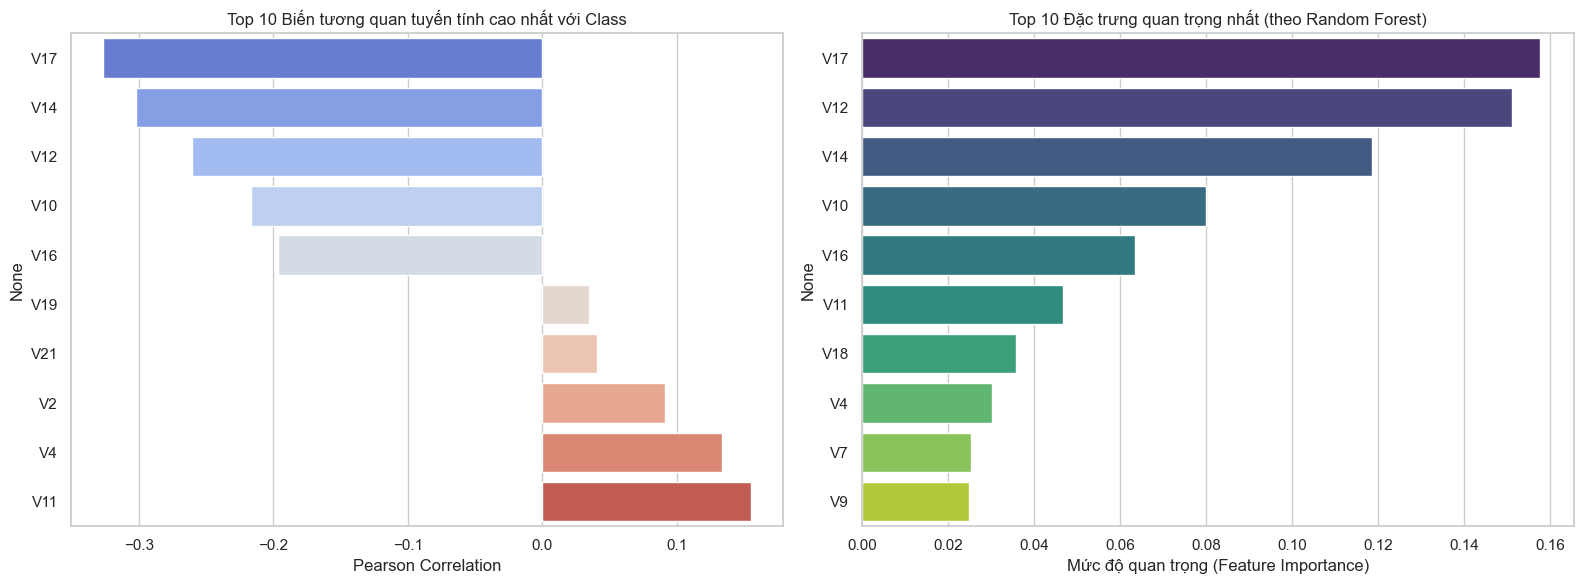

Check:
Kích thước dữ liệu gốc ban đầu: (284807, 31)
Kích thước dữ liệu sau khi tinh gọn: (284807, 16)


,V17,V12,V14,V10,V16,V11,V18,V4,V7,V9,V26,V3,V1,V13,V5,Class
0,0.207971,-0.617801,-0.311169,0.090794,-0.470401,-0.551600,0.025791,1.378155,0.239599,0.363787,-0.189115,2.536347,-1.359807,-0.991390,-0.338321,0
1,-0.114805,1.065235,-0.143772,-0.166974,0.463917,1.612727,-0.183361,0.448154,-0.078803,-0.255425,0.125895,0.166480,1.191857,0.489095,0.060018,0
2,1.109969,0.066084,-0.165946,0.207643,-2.890083,0.624501,-0.121359,0.379780,0.791461,-1.514654,-0.139097,1.773209,-1.358354,0.717293,-0.503198,0


In [ ]:
# 1. TÍNH MA TRẬN TƯƠNG QUAN
corr_matrix = df_encoded.corr()
corr_with_class = corr_matrix['Class'].drop('Class').sort_values()

# Lấy 5 biến tương quan nghịch mạnh nhất và 5 biến tương quan thuận mạnh nhất
top_features = pd.concat([corr_with_class.head(5), corr_with_class.tail(5)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_features.values, y=top_features.index, ax=axes[0], hue=top_features.index, palette='coolwarm', legend=False)
axes[0].set_title("Top 10 Biến tương quan tuyến tính cao nhất với Class")
axes[0].set_xlabel("Pearson Correlation")

# 2. SỬ DỤNG RANDOM FOREST FEATURE IMPORTANCE
# Lấy mẫu 20% dữ liệu để chạy Random Forest (không đủ RAM và đã đủ đại diện)
df_sample = df_encoded.sample(frac=0.2, random_state=42)
X_rf = df_sample.drop('Class', axis=1)
y_rf = df_sample['Class']

rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_rf, y_rf)

# Trực quan hóa Top 10 Features của RF
importances = pd.Series(rf_model.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, ax=axes[1], hue=importances.head(10).index, palette='viridis', legend=False)
axes[1].set_title("Top 10 Đặc trưng quan trọng nhất (theo Random Forest)")
axes[1].set_xlabel("Mức độ quan trọng (Feature Importance)")

plt.tight_layout()
plt.show()

# Chọn lấy 15 cột quan trọng nhất từ đánh giá của Random Forest
final_top_features = importances.head(15).index.tolist()
final_top_features.append('Class') # Phải giữ lại nhãn

df_final = df_encoded[final_top_features]

print("Check:")
print(f"Kích thước dữ liệu gốc ban đầu: {df.shape}")
print(f"Kích thước dữ liệu sau khi tinh gọn: {df_final.shape}")
display(df_final.head(3))

**Tổng kết Lựa chọn Đặc trưng:**

- Biểu đồ Barplot tương quan (bên trái) cho thấy `V17`, `V14`, `V12` có tương quan nghịch khá mạnh với `Class` (giá trị âm). Có nghĩa là các biến này mang giá trị càng nhỏ, rủi ro giao dịch đó là lừa đảo càng lớn. `V11` là một biến thuận quan trọng.
- Biểu đồ Random Forest (bên phải) cho thấy  bộ 3 `V17`, `V14`, `V12` có điểm cao nhất. 
- Đáng chú ý, các cột One-hot tạo ra từ thời gian (`Buoi_...`) dù có mang lại thông tin nhưng không được đánh giá quá cao so với các thành phần PCA đã được chắt lọc kỹ của ngân hàng.
- **Quyết định cuối cùng (Final Selection):** Để cân bằng giữa tốc độ tính toán và độ chính xác, nhóm quyết định giữ lại Top 15 đặc trưng có điểm Importance cao nhất. Lược bỏ đi hơn phân nửa số cột "nhiễu" không đóng góp giá trị. `df_final` giờ đây đã sạch và chuẩn hóa. Hoàn thành bước preprocessing.